**420-C74-SF - Techniques d'apprentissage automatique - Automne 2026 - Spécialiste en solutions d'intelligence artificielle**<br/>
© 2026 MKL.AI - Tous droits réservés
<br/>
![Atelier - Variables explicatives catégorielles](static/08-banner.png)
<br/>
**Objectif:** cette séance de travaux pratiques est consacrée à la transformation des variables explicatives catégorielles en **variables indicatrices**

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

### 0 - Chargement des bibliothèques

In [2]:
# Manipulation de données
import numpy as np
import pandas as pd

# Visualisation de données
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.decomposition import PCA

In [3]:
# Configuration de la visualisation
sns.set(style="darkgrid", rc={'figure.figsize':(11.7,8.27)})
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})

### 1 - Lecture du jeu de données *Heart*

**Exercice 1: lire le fichier `Heart.csv`**

In [4]:
# Compléter le code ci-dessous ~ 1 ligne
HRT = pd.read_csv('../../data/Heart.csv', index_col=0)

In [5]:
# On supprime les données manquantes. Ceci sera vu plus en détail plus tard dans le cours
HRT = HRT.dropna()

**Exercice 2: afficher les dix premières lignes de la trame de données**

In [6]:
# Compléter le code ci-dessous ~ 1 ligne
HRT.head(10)

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
6,56,1,nontypical,120,236,0,0,178,0,0.8,1,0.0,normal,No
7,62,0,asymptomatic,140,268,0,2,160,0,3.6,3,2.0,normal,Yes
8,57,0,asymptomatic,120,354,0,0,163,1,0.6,1,0.0,normal,No
9,63,1,asymptomatic,130,254,0,2,147,0,1.4,2,1.0,reversable,Yes
10,53,1,asymptomatic,140,203,1,2,155,1,3.1,3,0.0,reversable,Yes


**Exercice 3: quel est le type de données (dtype) du ndarray sous-jacent ?**

In [7]:
# Compléter le code ci-dessous ~ 1 ligne
HRT.values.dtype

dtype('O')

**Exercice 4: trouver tous les niveaux des variables catégorielles**<br/>
Indice: vous devrez utilisez la méthode `unique()` de pandas

In [8]:
# Compléter le code ci-dessous ~ 3 lignes
print('ChestPain:', HRT['ChestPain'].unique())
print('Thal:', HRT['Thal'].unique())
print('AHD:', HRT['AHD'].unique())

ChestPain: <StringArray>
['typical', 'asymptomatic', 'nonanginal', 'nontypical']
Length: 4, dtype: str
Thal: <StringArray>
['fixed', 'normal', 'reversable']
Length: 3, dtype: str
AHD: <StringArray>
['No', 'Yes']
Length: 2, dtype: str


### 2 - Création des variables indicatrices

**Exercice 5: créer les variables indicatrices**<br/>

In [9]:
#pd.get_dummies(HRT['ChestPain'], prefix='ChestPain', dtype=int, drop_first=True)

In [10]:
# Compléter le code ci-dessous ~ 7 lignes
# Variables explicatives à k niveaux => k-1 variables indicatrices (drop_first=True)
chestpain_dummies = pd.get_dummies(HRT['ChestPain'], prefix='ChestPain', drop_first=True, dtype=int)
thal_dummies = pd.get_dummies(HRT['Thal'], prefix='Thal', drop_first=True, dtype=int)
HRT = pd.concat([HRT.drop(['ChestPain', 'Thal'], axis=1), chestpain_dummies, thal_dummies], axis=1)
HRT
# Variable réponse binaire => 0 / 1
HRT['AHD'] = HRT['AHD'].map({'No': 0, 'Yes': 1})
HRT.head(10)

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
1,63,1,145,233,1,2,150,0,2.3,3,0.0,0,0,0,1,0,0
2,67,1,160,286,0,2,108,1,1.5,2,3.0,1,0,0,0,1,0
3,67,1,120,229,0,2,129,1,2.6,2,2.0,1,0,0,0,0,1
4,37,1,130,250,0,0,187,0,3.5,3,0.0,0,1,0,0,1,0
5,41,0,130,204,0,2,172,0,1.4,1,0.0,0,0,1,0,1,0
6,56,1,120,236,0,0,178,0,0.8,1,0.0,0,0,1,0,1,0
7,62,0,140,268,0,2,160,0,3.6,3,2.0,1,0,0,0,1,0
8,57,0,120,354,0,0,163,1,0.6,1,0.0,0,0,0,0,1,0
9,63,1,130,254,0,2,147,0,1.4,2,1.0,1,0,0,0,0,1
10,53,1,140,203,1,2,155,1,3.1,3,0.0,1,0,0,0,0,1


**Exercice 6: quel est maintenant le type de données (dtype) du ndarray sous-jacent ?**

In [11]:
# Compléter le code ci-dessous ~ 1 ligne
HRT.values.dtype

dtype('float64')

### 3 - Affichages des composante principales (contenu non inclus dans aujourd'hui)

In [13]:
X = HRT.drop(['AHD'], axis=1).values
y = HRT.AHD.values
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)
X_pca

array([[-1.33233032e+01, -2.92420332e+00],
       [ 4.05746571e+01, -4.56119117e+01],
       [-1.84032483e+01, -2.13557901e+01],
       [ 1.83109167e+00,  3.98888732e+01],
       [-4.38923789e+01,  2.39020390e+01],
       [-1.19332931e+01,  2.86703973e+01],
       [ 2.13007271e+01,  8.06677942e+00],
       [ 1.05896557e+02,  1.55658474e+01],
       [ 6.87243821e+00, -3.80559908e+00],
       [-4.38981038e+01,  3.88388382e+00],
       [-5.47240564e+01, -3.75649607e+00],
       [ 4.70321734e+01,  2.78486127e+00],
       [ 8.61722373e+00, -7.37028911e+00],
       [ 1.45758329e+01,  2.63694357e+01],
       [-4.63083740e+01,  7.23717406e+00],
       [-7.82113125e+01,  2.01157444e+01],
       [-1.97096062e+01,  2.13785090e+01],
       [-7.95252688e+00,  9.19120976e+00],
       [ 2.72797090e+01, -8.51416223e+00],
       [ 1.82724298e+01,  2.23995975e+01],
       [-3.70259383e+01, -5.23025733e+00],
       [ 3.66242395e+01,  9.90426388e+00],
       [ 3.60858301e+01,  1.14032158e+01],
       [-2.

Text(0, 0.5, 'PC2')

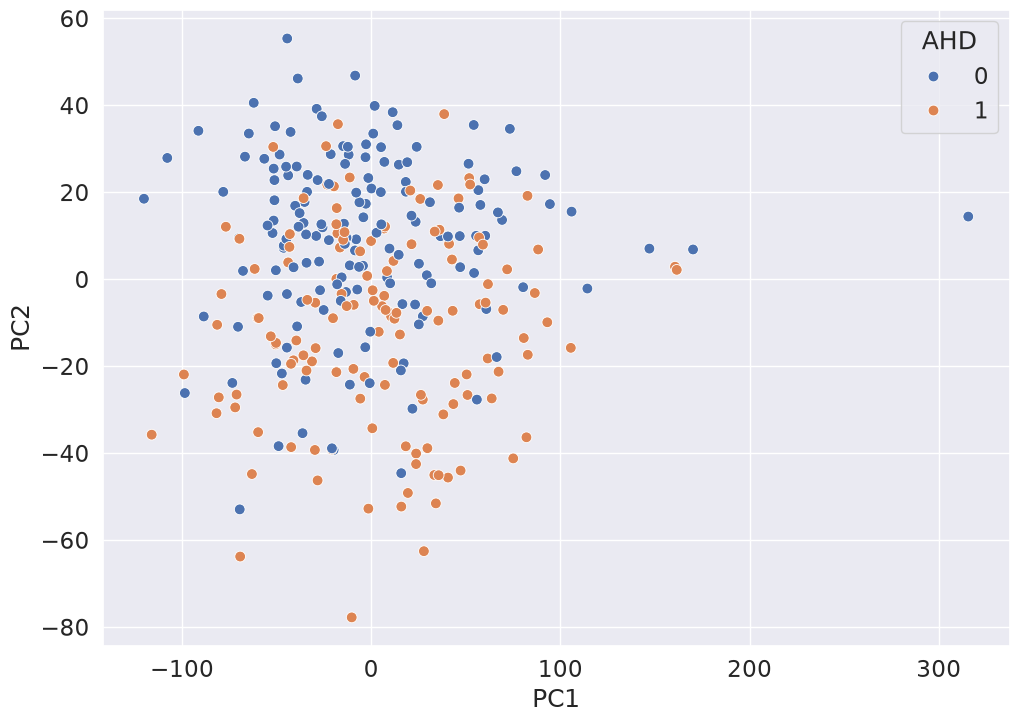

In [14]:
ax = sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=HRT['AHD'], s = 60)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

### Fin de l'atelier